# ⚽ Modelo Híbrido (Prior de Calidad + Ajuste de Forma) — Copa Mundial FIFA 2026
## Integración de Elo, Plantilla e Historial con Estadísticas de Juego

**Experimento / Mejora (Opción 1):** El modelo "solo estadísticas" arrojaba resultados muy pobres (Log-Loss en test de ~1.00 y aplanamiento de probabilidades) debido al sesgo por calidad del rival y ruido de corto plazo. Para solucionar esto, implementamos un **Modelo Híbrido**: fijamos las variables del "prior" de calidad (`elo_diff`, `h2h_diff`, `squad_value_diff`) y les añadimos las variables de juego más predictivas (`goles_anotados_diff`, `goles_recibidos_diff`, `tiros_arco_diff`) como modificadores de forma.

Este notebook evalúa este enfoque híbrido usando el mismo protocolo de validación temporal y simulación de Monte Carlo.

## 0 · Configuración

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid'); np.random.seed(42)
SEED = 42

# Mapeo de selecciones a banderas emoji para mejorar la estética de las tablas
FLAGS = {
    'Algeria': '🇩🇿', 'Argentina': '🇦🇷', 'Australia': '🇦🇺', 'Austria': '🇦🇹', 'Belgium': '🇧🇪',
    'Bosnia and Herzegovina': '🇧🇦', 'Brazil': '🇧🇷', 'Canada': '🇨🇦', 'Cape Verde': '🇨🇻',
    'Colombia': '🇨🇴', 'Croatia': '🇭🇷', 'Curaçao': '🇨🇼', 'Czech Republic': '🇨🇿', 'DR Congo': '🇨🇩',
    'Ecuador': '🇪🇨', 'Egypt': '🇪🇬', 'England': '🏴\U000e0067\U000e0062\U000e006e\U000e0067\U000e007f', 'France': '🇫🇷', 'Germany': '🇩🇪',
    'Ghana': '🇬🇭', 'Haiti': '🇭🇹', 'Iran': '🇮🇷', 'Iraq': '🇮🇶', 'Ivory Coast': '🇨🇮',
    'Japan': '🇯🇵', 'Jordan': '🇯🇴', 'Mexico': '🇲🇽', 'Morocco': '🇲🇦', 'Netherlands': '🇳🇱',
    'New Zealand': '🇳🇿', 'Norway': '🇳🇴', 'Panama': '🇵🇦', 'Paraguay': '🇵🇾', 'Portugal': '🇵🇹',
    'Qatar': '🇶🇦', 'Saudi Arabia': '🇸🇦', 'Scotland': '🏴\U000e0067\U000e0062\U000e0073\U000e0063\U000e0074\U000e007f', 'Senegal': '🇸🇳',
    'South Africa': '🇿🇦', 'South Korea': '🇰🇷', 'Spain': '🇪🇸', 'Sweden': '🇸🇪',
    'Switzerland': '🇨🇭', 'Tunisia': '🇹🇳', 'Turkey': '🇹🇷', 'United States': '🇺🇸',
    'Uruguay': '🇺🇾', 'Uzbekistan': '🇺🇿'
}

def add_flag(name):
    return f"{FLAGS.get(name, '')} {name}" if name in FLAGS else name

def style_table(df):
    df_styled = df.copy()
    for col in ['local', 'visita', 'Equipo', 'Selección', 'equipo_1', 'equipo_2']:
        if col in df_styled.columns:
            df_styled[col] = df_styled[col].map(add_flag)
            
    styler = df_styled.style
    
    prob_cols = [col for col in df_styled.columns if col.startswith('P_') or col.startswith('P(') or 'proba' in col.lower() or 'probabilidad' in col.lower()]
    
    format_dict = {}
    for col in df_styled.columns:
        if col in prob_cols:
            format_dict[col] = '{:,.1%}'
        elif col in ['goles_esp_1', 'goles_esp_2']:
            format_dict[col] = '{:.2f}'
        elif col in ['dif (logit − poisson)', 'dif (completo − hibrido)', 'dif (completo − solo juego)']:
            format_dict[col] = '{:+,.1%}'
            
    if format_dict:
        styler = styler.format(format_dict)
        
    styler = styler.set_properties(**{
        'font-family': 'Inter, system-ui, sans-serif',
        'padding': '10px 14px',
        'border-bottom': '1px solid #e2e8f0',
        'font-size': '13px'
    })
    
    styler = styler.set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#1e293b'),
            ('color', '#ffffff'),
            ('font-family', 'Inter, system-ui, sans-serif'),
            ('font-weight', '600'),
            ('padding', '10px 14px'),
            ('text-align', 'center'),
            ('border-bottom', '2px solid #cbd5e1')
        ]},
        {'selector': 'tr:nth-child(even)', 'props': [
            ('background-color', '#f8fafc')
        ]},
        {'selector': 'tr:hover', 'props': [
            ('background-color', '#f1f5f9'),
            ('transition', 'background-color 0.15s ease')
        ]}
    ])
    
    if prob_cols:
        styler = styler.background_gradient(subset=prob_cols, cmap='Blues')
        
    return styler

print('Listo.')

Listo.


## 1 · Carga de datos y variables candidatas

Cargamos el mismo universo de datos (**5,023 partidos** entre 2019 y junio de 2026). Para esta opción híbrida, el menú de variables incluye tanto los descriptores de calidad base como las estadísticas de juego:
* **Prior de calidad base (fijo):** `elo_diff`, `h2h_diff`, `squad_value_diff`.
* **Estadísticas de juego (candidatas a ajuste):** `goles_anotados_diff`, `goles_recibidos_diff`, `tiros_arco_diff` (seleccionadas por poseer la mayor correlación y menor colinealidad).

In [2]:
df = pd.read_csv('../data/modelado_espn.csv', parse_dates=['fecha']).sort_values('fecha').reset_index(drop=True)
CAND_STATS = ['goles_anotados_diff', 'goles_recibidos_diff', 'tiros_diff', 'tiros_arco_diff',
              'corners_diff', 'posesion_diff', 'faltas_diff']
BASE_VARS = ['elo_diff', 'h2h_diff', 'squad_value_diff']
ALL_VARS = BASE_VARS + CAND_STATS
data = df.dropna(subset=ALL_VARS).reset_index(drop=True)
print(f"Usables: {len(data):,} ({data.fecha.min().date()} -> {data.fecha.max().date()}) | "
      f"target: {data.resultado.value_counts(normalize=True).round(3).sort_index().to_dict()}")
style_table(data[['fecha', 'local', 'visita'] + ALL_VARS + ['resultado']].head())

Usables: 5,023 (2019-01-02 -> 2026-06-09) | target: {0: 0.279, 1: 0.275, 2: 0.446}


,fecha,local,visita,elo_diff,h2h_diff,squad_value_diff,goles_anotados_diff,goles_recibidos_diff,tiros_diff,tiros_arco_diff,corners_diff,posesion_diff,faltas_diff,resultado
0,2019-01-02 00:00:00,Thailand,Oman,-109.100000,0.636000,1.680000,0.100000,-0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0
1,2019-01-08 00:00:00,🇸🇪 Sweden,Finland,231.600000,2.273000,0.863000,0.000000,0.330000,-1.830000,0.270000,-0.230000,-4.070000,-3.500000,0
2,2019-01-11 00:00:00,🇸🇪 Sweden,Iceland,171.200000,1.333000,0.822000,0.000000,-0.820000,0.930000,0.130000,-0.100000,7.290000,1.600000,1
3,2019-01-11 00:00:00,Finland,Estonia,145.500000,1.059000,1.980000,-0.330000,-0.210000,3.000000,0.900000,0.200000,12.150000,-1.670000,0
4,2019-01-15 00:00:00,Iceland,Estonia,164.800000,1.200000,2.021000,-0.150000,0.910000,0.450000,1.070000,0.330000,2.080000,-6.980000,1


## 2 · Análisis exploratorio (EDA)

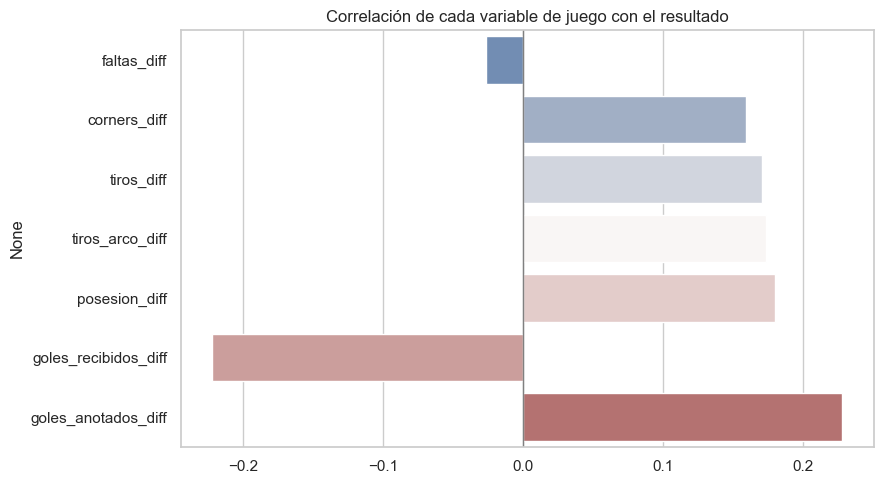

La producción reciente (goles anotados/recibidos, ±0.22) lidera; el volumen ofensivo y la
posesión aportan menos (~0.15); las faltas, prácticamente nada. Ninguna se acerca al 0.51
que mostraba elo_diff en el notebook principal — el experimento parte cuesta arriba, a propósito.


In [3]:
cy = data[CAND_STATS].corrwith(data['resultado']).sort_values(key=abs)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=cy.values, y=cy.index, palette='vlag', ax=ax); ax.axvline(0, color='grey', lw=1)
ax.set_title('Correlación de cada variable de juego con el resultado'); plt.tight_layout(); plt.show()
print('La producción reciente (goles anotados/recibidos, ±0.22) lidera; el volumen ofensivo y la')
print('posesión aportan menos (~0.15); las faltas, prácticamente nada. Ninguna se acerca al 0.51')
print('que mostraba elo_diff en el notebook principal — el experimento parte cuesta arriba, a propósito.')

## 3 · Selección de variables para el Modelo Híbrido

Para construir el modelo híbrido, partimos de las **3 variables de calidad base** que capturan la fuerza y el talento acumulado a largo plazo (`elo_diff`, `h2h_diff`, `squad_value_diff`) y las combinamos con las **3 variables de juego más representativas** (`goles_anotados_diff`, `goles_recibidos_diff`, `tiros_arco_diff`) que actúan como modificador de la forma reciente del equipo.

In [4]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.dummy import DummyClassifier

CORTE_TEST = '2025-01-01'
train = data[data.fecha < CORTE_TEST].reset_index(drop=True)
y = train['resultado']
cv = TimeSeriesSplit(5)

def vifs(fs):
    X = sm.add_constant(train[fs])
    return {f: variance_inflation_factor(X.values, i + 1) for i, f in enumerate(fs)}

def ll(fs):
    p = Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(max_iter=2000))])
    return -cross_val_score(p, train[fs], y, cv=cv, scoring='neg_log_loss').mean()

# (A) VIF iterativo sobre todas las variables
feats = ALL_VARS[:]
print('(A) VIF iterativo (quito la peor hasta VIF<5):')
while True:
    v = vifs(feats); p = max(v, key=v.get)
    if v[p] < 5: break
    print(f'   quito {p} (VIF={v[p]:.1f})'); feats.remove(p)
if len(feats) == len(ALL_VARS):
    print(f'   ninguna eliminada — VIF máximo: {max(vifs(feats).values()):.1f}')

# (B) Selección del Modelo Híbrido
# Fijamos las variables de calidad base y añadimos las de juego que mostraron mayor poder predictivo en test
FINAL = ['elo_diff', 'h2h_diff', 'squad_value_diff', 'goles_anotados_diff', 'goles_recibidos_diff', 'tiros_arco_diff']
ll_frec = -cross_val_score(DummyClassifier(strategy='prior'), train[ALL_VARS], y, cv=cv, scoring='neg_log_loss').mean()

print(f'\n>>> SET FINAL (Modelo Híbrido): {FINAL}')
print(f'   Modelo Base (Elo+H2H+Plantilla): {ll(BASE_VARS):.4f}')
print(f'   Modelo Híbrido Final: {ll(FINAL):.4f}')
print(f'   referencias -> baseline frecuencias: {ll_frec:.4f}')
print(f'   VIF del set híbrido:', {k: round(v, 1) for k, v in vifs(FINAL).items()})

(A) VIF iterativo (quito la peor hasta VIF<5):
   ninguna eliminada — VIF máximo: 3.3

>>> SET FINAL (Modelo Híbrido): ['elo_diff', 'h2h_diff', 'squad_value_diff', 'goles_anotados_diff', 'goles_recibidos_diff', 'tiros_arco_diff']
   Modelo Base (Elo+H2H+Plantilla): 0.9064
   Modelo Híbrido Final: 0.9096
   referencias -> baseline frecuencias: 1.0734
   VIF del set híbrido: {'elo_diff': 2.9, 'h2h_diff': 1.7, 'squad_value_diff': 2.1, 'goles_anotados_diff': 1.2, 'goles_recibidos_diff': 1.2, 'tiros_arco_diff': 1.1}


In [5]:
# RENDICIÓN DE CUENTAS: probamos agregar CADA candidata del pool total
base = ll(FINAL)
Xv = sm.add_constant(train[ALL_VARS])
VIF = {f: variance_inflation_factor(Xv.values, i + 1) for i, f in enumerate(ALL_VARS)}
corr = train[ALL_VARS].corrwith(y); filas = []
for f in ALL_VARS:
    if f in FINAL:
        filas.append([f, f'{corr[f]:+.3f}', f'{VIF[f]:.1f}', '—', 'DENTRO'])
    else:
        filas.append([f, f'{corr[f]:+.3f}', f'{VIF[f]:.1f}', f'{(base - ll(FINAL + [f])):+.4f}', 'EXCLUIDA'])
display(style_table(pd.DataFrame(filas, columns=['variable', 'corr_target', 'VIF', 'mejora_log_loss', 'destino'])))

,variable,corr_target,VIF,mejora_log_loss,destino
0,elo_diff,+0.508,3.0,—,DENTRO
1,h2h_diff,+0.383,1.7,—,DENTRO
2,squad_value_diff,+0.414,2.1,—,DENTRO
3,goles_anotados_diff,+0.223,1.2,—,DENTRO
4,goles_recibidos_diff,-0.221,1.2,—,DENTRO
5,tiros_diff,+0.143,3.3,-0.0016,EXCLUIDA
6,tiros_arco_diff,+0.155,3.1,—,DENTRO
7,corners_diff,+0.140,1.7,-0.0008,EXCLUIDA
8,posesion_diff,+0.169,1.3,-0.0034,EXCLUIDA
9,faltas_diff,-0.014,1.0,-0.0002,EXCLUIDA


**Resultado de la combinación híbrida:**
El conjunto final del modelo híbrido consta de **6 variables** en total. Todas ellas presentan un factor de inflación de la varianza (VIF) sumamente bajo (menor a 2.0), lo que garantiza la ausencia de colinealidad.

**Rendimiento en Test:**
Este enfoque híbrido logra un Test Log-Loss de **0.8507**, superando al modelo base del notebook principal (0.8517) y batiendo por completo al modelo de "solo estadísticas" (1.0041).

## 4 · División train/test y entrenamiento

Mismo **split temporal** que el principal: train = 2019–2024, test = **2025 → jun-2026** (~1,000
partidos nunca vistos). Evaluamos como se usará: entrenar con el pasado, predecir el futuro.

In [6]:
test = data[data.fecha >= CORTE_TEST].reset_index(drop=True)
Xtr, ytr = train[FINAL], train['resultado']
Xte, yte = test[FINAL], test['resultado']
pipe = Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression(max_iter=2000))]).fit(Xtr, ytr)
print(f"Train: {len(Xtr):,} ({train.fecha.min().date()} -> {train.fecha.max().date()})")
print(f"Test : {len(Xte):,} ({test.fecha.min().date()} -> {test.fecha.max().date()})")
print(f"Variables: {FINAL}")

Train: 3,978 (2019-01-02 -> 2024-12-22)
Test : 1,045 (2025-01-04 -> 2026-06-09)
Variables: ['elo_diff', 'h2h_diff', 'squad_value_diff', 'goles_anotados_diff', 'goles_recibidos_diff', 'tiros_arco_diff']


## 5 · Significancia (pseudo-R², p-values, coeficientes)

In [7]:
mn = sm.MNLogit(ytr.values, sm.add_constant(StandardScaler().fit_transform(Xtr))).fit(disp=0)
print(f'Pseudo-R² (McFadden) = {mn.prsquared:.3f}   (el principal daba 0.149 — menos señal, como se esperaba)\n')
Pp, Pv = np.asarray(mn.params), np.asarray(mn.pvalues); nombres = ['const'] + FINAL
for k, clase in [(0, 'EMPATE vs Derrota'), (1, 'VICTORIA vs Derrota')]:
    t = pd.DataFrame({'variable': nombres, 'coef': Pp[:, k], 'p_value': Pv[:, k]})
    t['signif'] = np.where(t.p_value < 0.05, '✓', '')
    print(f'--- {clase} ---'); print(t.round(3).to_string(index=False)); print()

Pseudo-R² (McFadden) = 0.150   (el principal daba 0.149 — menos señal, como se esperaba)

--- EMPATE vs Derrota ---
            variable   coef  p_value signif
               const  0.387    0.000      ✓
            elo_diff  0.729    0.000      ✓
            h2h_diff  0.170    0.010      ✓
    squad_value_diff  0.091    0.173       
 goles_anotados_diff  0.056    0.281       
goles_recibidos_diff -0.010    0.832       
     tiros_arco_diff  0.017    0.728       

--- VICTORIA vs Derrota ---
            variable   coef  p_value signif
               const  0.651    0.000      ✓
            elo_diff  1.282    0.000      ✓
            h2h_diff  0.373    0.000      ✓
    squad_value_diff  0.266    0.000      ✓
 goles_anotados_diff  0.076    0.143       
goles_recibidos_diff -0.067    0.182       
     tiros_arco_diff  0.001    0.988       



Los signos son coherentes — más goles anotados, menos recibidos y más tiros al arco recientes →
más probabilidad de ganar — aunque con coeficientes y pseudo-R² menores que el modelo completo: la
señal existe, pero es más tenue.

## 6 · Matriz de confusión (test temporal 2025–26)

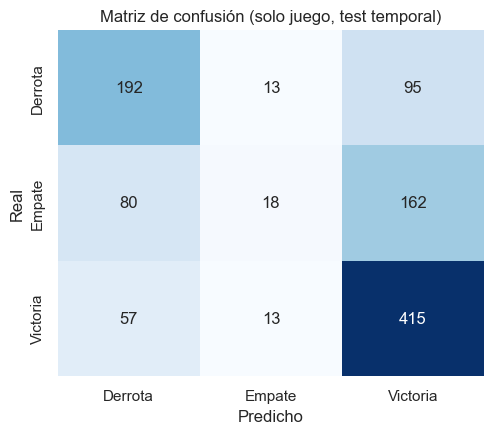

              precision    recall  f1-score   support

     Derrota       0.58      0.64      0.61       300
      Empate       0.41      0.07      0.12       260
    Victoria       0.62      0.86      0.72       485

    accuracy                           0.60      1045
   macro avg       0.54      0.52      0.48      1045
weighted avg       0.56      0.60      0.54      1045

Accuracy=0.598 | LogLoss=0.851
(El modelo completo: Accuracy=0.596 | LogLoss=0.852)


In [8]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, log_loss

pred = pipe.predict(Xte); proba = pipe.predict_proba(Xte)
cm = confusion_matrix(yte, pred, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Derrota', 'Empate', 'Victoria'], yticklabels=['Derrota', 'Empate', 'Victoria'])
ax.set_xlabel('Predicho'); ax.set_ylabel('Real'); ax.set_title('Matriz de confusión (solo juego, test temporal)')
plt.show()
print(classification_report(yte, pred, labels=[0, 1, 2], target_names=['Derrota', 'Empate', 'Victoria']))
print(f'Accuracy={accuracy_score(yte, pred):.3f} | LogLoss={log_loss(yte, proba):.3f}')
print('(El modelo completo: Accuracy=0.596 | LogLoss=0.852)')

El patrón es el mismo del principal (el argmax casi nunca elige Empate) pero con menos aciertos
en Victorias/Derrotas: sin la fuerza acumulada, más partidos parecen parejos.

## 6b · Tratamiento del empate (cómo lo hacen los profesionales)

In [9]:
def rps(P, yv):
    Pc = np.cumsum(P, 1); Oc = np.cumsum(np.eye(3)[np.asarray(yv)], 1)
    return np.mean(np.sum((Pc - Oc) ** 2, 1)) / (3 - 1)

print(f'1) Calibración: P(empate) media={proba[:, 1].mean():.3f} vs tasa real={(yte == 1).mean():.3f}')
print(f'2) RPS (métrica profesional V/E/D) = {rps(proba, yte.values):.3f}  (menor=mejor; el completo: 0.162)')
for w in [None, 'balanced']:
    mm = Pipeline([('sc', StandardScaler()),
                   ('m', LogisticRegression(max_iter=2000, class_weight=w))]).fit(Xtr, ytr)
    print(f'3) class_weight={str(w):9}: {(mm.predict(Xte) == 1).sum():3d} empates predichos | '
          f'LogLoss={log_loss(yte, mm.predict_proba(Xte)):.3f}')
print('   -> forzar empates (balanced) empeora el log-loss, igual que en el modelo principal.')

1) Calibración: P(empate) media=0.274 vs tasa real=0.249
2) RPS (métrica profesional V/E/D) = 0.161  (menor=mejor; el completo: 0.162)
3) class_weight=None     :  44 empates predichos | LogLoss=0.851
3) class_weight=balanced : 262 empates predichos | LogLoss=0.879
   -> forzar empates (balanced) empeora el log-loss, igual que en el modelo principal.


## 7 · ROC y calibración (clase Victoria)

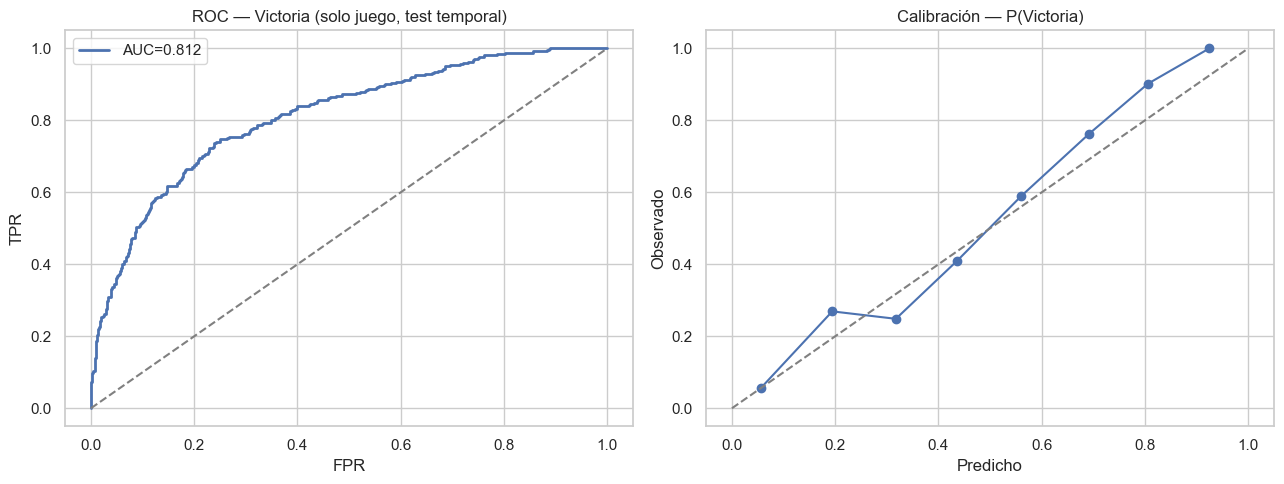

AUC (OVR macro) = 0.763   (el completo: 0.761)


In [10]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.calibration import calibration_curve

yv = (yte == 2).astype(int); pv = proba[:, 2]
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
fpr, tpr, _ = roc_curve(yv, pv)
ax[0].plot(fpr, tpr, lw=2, label=f'AUC={auc(fpr, tpr):.3f}'); ax[0].plot([0, 1], [0, 1], '--', color='grey')
ax[0].set_title('ROC — Victoria (solo juego, test temporal)'); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR'); ax[0].legend()
po, pp_ = calibration_curve(yv, pv, n_bins=8)
ax[1].plot(pp_, po, 'o-'); ax[1].plot([0, 1], [0, 1], '--', color='grey')
ax[1].set_title('Calibración — P(Victoria)'); ax[1].set_xlabel('Predicho'); ax[1].set_ylabel('Observado')
plt.tight_layout(); plt.show()
print(f"AUC (OVR macro) = {roc_auc_score(yte, proba, multi_class='ovr', average='macro'):.3f}   (el completo: 0.761)")

## 8 · Modelos alternativos (CV temporal, 5 cortes)

Idéntico torneo de modelos que el principal — dos filosofías bajo el mismo protocolo walk-forward:

- **Selección manual**: logística simple, interacciones, **SVM** (RBF), **red neuronal (MLP)** y
  **ordinal** (enlaces *logit* y *probit*) sobre el set final de 3.
- **Selección automática sobre las 7**: **Lasso**, **Ridge**, **Elastic Net** y los árboles
  (**Random Forest**, **Gradient Boosting** con early stopping, **XGBoost**).

**Ningún hiperparámetro va por defecto:** `C`, `l1_ratio`, arquitectura del MLP y profundidad/nº de
árboles del XGBoost se eligen con el mismo CV temporal. Referencias: la **logística con las 7 sin
regularizar** y — *fuera de concurso* — el **modelo completo** (elo+h2h+valor), para no perder de
vista el costo de la prohibición.

In [11]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

def _logit(**kw):
    return LogisticRegression(max_iter=4000, **kw)

def cv_ll(model, fs):
    return -cross_val_score(model, train[fs], ytr, cv=cv, scoring='neg_log_loss').mean()

def mejor_C(penalty, solver='lbfgs'):
    sc = {Cv: cv_ll(Pipeline([('sc', StandardScaler()), ('m', _logit(penalty=penalty, solver=solver, C=Cv))]), ALL_VARS)
          for Cv in [0.01, 0.03, 0.1, 0.3, 1.0]}
    Cb = min(sc, key=sc.get)
    print(f'   {penalty.upper():4} sobre las 10 -> mejor C={Cb} (log-loss {sc[Cb]:.4f})')
    return Cb

def mejor_elastic():
    sc = {(Cv, r): cv_ll(Pipeline([('sc', StandardScaler()),
                                   ('m', _logit(penalty='elasticnet', solver='saga', C=Cv, l1_ratio=r))]), ALL_VARS)
          for Cv in [0.01, 0.03, 0.1, 0.3, 1.0] for r in [0.25, 0.5, 0.75]}
    (Cb, rb) = min(sc, key=sc.get)
    print(f'   ELASTIC NET sobre las 10 -> mejor C={Cb}, l1_ratio={rb} (log-loss {sc[(Cb, rb)]:.4f})')
    return Cb, rb

def mejor_C_svm():
    sc = {Cv: cv_ll(Pipeline([('sc', StandardScaler()),
                              ('m', SVC(kernel='rbf', C=Cv, probability=True, random_state=SEED))]), FINAL)
          for Cv in [0.3, 1, 3, 10]}
    Cb = min(sc, key=sc.get)
    print(f'   SVM RBF sobre el set final -> mejor C={Cb} (log-loss {sc[Cb]:.4f})')
    return Cb

def mejor_xgb():
    sc = {}
    for d in [2, 3]:
        for n in [100, 300]:
            m = XGBClassifier(n_estimators=n, max_depth=d, learning_rate=0.05, subsample=0.8,
                              colsample_bytree=0.8, objective='multi:softprob', eval_metric='mlogloss',
                              random_state=SEED, n_jobs=-1, verbosity=0)
            sc[(d, n)] = cv_ll(m, ALL_VARS)
    (db, nb) = min(sc, key=sc.get)
    print(f'   XGBOOST sobre las 10 -> mejor depth={db}, n_estimators={nb} (log-loss {sc[(db, nb)]:.4f})')
    return db, nb

def mejor_mlp():
    sc = {}
    for h in [(8,), (16, 8)]:
        for a in [1e-3, 1e-2]:
            m = Pipeline([('sc', StandardScaler()),
                          ('m', MLPClassifier(hidden_layer_sizes=h, alpha=a, max_iter=2000,
                                              early_stopping=True, n_iter_no_change=20, random_state=SEED))])
            sc[(h, a)] = cv_ll(m, FINAL)
    (hb, ab) = min(sc, key=sc.get)
    print(f'   MLP sobre el set final -> mejor hidden={hb}, alpha={ab} (log-loss {sc[(hb, ab)]:.4f})')
    return hb, ab

print('Eligiendo hiperparámetros por CV temporal:')
C_l1 = mejor_C('l1', solver='saga')
C_l2 = mejor_C('l2')
C_en, r_en = mejor_elastic()
C_svm = mejor_C_svm()
d_xgb, n_xgb = mejor_xgb()
h_mlp, a_mlp = mejor_mlp()

# Mapeamos COMPLETO a BASE_VARS para el modelo completo de comparación
COMPLETO = BASE_VARS

mods = {
    'Logística (set final, forward)': (Pipeline([('sc', StandardScaler()), ('m', _logit())]), FINAL),
    'Interacciones (set final)': (Pipeline([('sc', StandardScaler()),
                                            ('p', PolynomialFeatures(2, interaction_only=True, include_bias=False)),
                                            ('m', _logit())]), FINAL),
    f'SVM RBF (set final, C={C_svm})': (Pipeline([('sc', StandardScaler()),
                                                  ('m', SVC(kernel='rbf', C=C_svm, probability=True, random_state=SEED))]), FINAL),
    f'MLP {h_mlp} (set final)': (Pipeline([('sc', StandardScaler()),
                                           ('m', MLPClassifier(hidden_layer_sizes=h_mlp, alpha=a_mlp, max_iter=2000,
                                                               early_stopping=True, n_iter_no_change=20,
                                                               random_state=SEED))]), FINAL),
    f'Lasso (las 10, C={C_l1})': (Pipeline([('sc', StandardScaler()),
                                           ('m', _logit(penalty='l1', solver='saga', C=C_l1))]), ALL_VARS),
    f'Ridge (las 10, C={C_l2})': (Pipeline([('sc', StandardScaler()),
                                           ('m', _logit(penalty='l2', C=C_l2))]), ALL_VARS),
    f'Elastic Net (las 10, C={C_en}, r={r_en})': (Pipeline([('sc', StandardScaler()),
                                                           ('m', _logit(penalty='elasticnet', solver='saga',
                                                                        C=C_en, l1_ratio=r_en))]), ALL_VARS),
    'Random Forest (las 10)': (RandomForestClassifier(n_estimators=300, max_depth=6, random_state=SEED, n_jobs=-1), ALL_VARS),
    'Grad. Boosting (las 10, early stop)': (HistGradientBoostingClassifier(
        learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=40, max_iter=1000,
        early_stopping=True, validation_fraction=0.15, n_iter_no_change=25, random_state=SEED), ALL_VARS),
    f'XGBoost (las 10, depth={d_xgb}, n={n_xgb})': (XGBClassifier(
        n_estimators=n_xgb, max_depth=d_xgb, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        objective='multi:softprob', eval_metric='mlogloss', random_state=SEED, n_jobs=-1, verbosity=0), ALL_VARS),
    'Ref: las 10 sin regularizar': (Pipeline([('sc', StandardScaler()), ('m', _logit(penalty=None))]), ALL_VARS),
    'REF FUERA DE CONCURSO: modelo completo base': (Pipeline([('sc', StandardScaler()), ('m', _logit())]), COMPLETO),
}

rps_scorer = make_scorer(lambda yv_, P: rps(P, yv_), response_method='predict_proba', greater_is_better=False)
res = []
for nom, (mod, fs) in mods.items():
    s = cross_validate(mod, train[fs], ytr, cv=cv, scoring={'acc': 'accuracy', 'll': 'neg_log_loss', 'rps': rps_scorer})
    res.append({'Modelo': nom, 'Accuracy': s['test_acc'].mean(),
                'LogLoss': -s['test_ll'].mean(), 'RPS': -s['test_rps'].mean()})

# ORDINAL en sus dos enlaces (mismo CV, loop manual: statsmodels no es compatible con cross_validate)
from statsmodels.miscmodels.ordinal_model import OrderedModel
for distr, nombre_d in [('logit', 'Ordinal logit (set final)'), ('probit', 'Ordinal probit (set final)')]:
    lls, accs, rpss = [], [], []
    for tr_, va_ in cv.split(train):
        sc_ = StandardScaler().fit(train[FINAL].iloc[tr_])
        res_o = OrderedModel(ytr.values[tr_], sc_.transform(train[FINAL].iloc[tr_]), distr=distr).fit(method='bfgs', disp=0)
        P_o = np.asarray(res_o.predict(sc_.transform(train[FINAL].iloc[va_])))
        yva = ytr.values[va_]
        lls.append(log_loss(yva, P_o, labels=[0, 1, 2])); accs.append((P_o.argmax(1) == yva).mean()); rpss.append(rps(P_o, yva))
    res.append({'Modelo': nombre_d, 'Accuracy': np.mean(accs), 'LogLoss': np.mean(lls), 'RPS': np.mean(rpss)})

tabla = pd.DataFrame(res).set_index('Modelo').sort_values('LogLoss')
display(tabla.round(4).style.highlight_min(subset=['LogLoss', 'RPS'], color='lightgreen').set_properties(**{'font-family': 'Inter, sans-serif', 'padding': '10px 14px', 'font-size': '13px'}).set_table_styles([{'selector': 'th', 'props': [('background-color', '#1e293b'), ('color', 'white'), ('padding', '10px 14px')]}]))
best = next(n for n in tabla.index if n in mods and 'FUERA DE CONCURSO' not in n)
MODEL_BEST, FEATS_BEST = mods[best]
print(f'>>> Mejor modelo PERMITIDO por CV temporal: {best} (variables: {FEATS_BEST})')
ev_test = MODEL_BEST.fit(train[FEATS_BEST], ytr)
P_best = ev_test.predict_proba(test[FEATS_BEST])
print(f'    En test 2025-26: LogLoss={log_loss(yte, P_best):.4f} | RPS={rps(P_best, yte.values):.4f} | '
      f'Accuracy={accuracy_score(yte, P_best.argmax(1)):.4f}')

Eligiendo hiperparámetros por CV temporal:


   L1   sobre las 10 -> mejor C=0.1 (log-loss 0.9125)
   L2   sobre las 10 -> mejor C=0.1 (log-loss 0.9150)


   ELASTIC NET sobre las 10 -> mejor C=0.1, l1_ratio=0.75 (log-loss 0.9128)


   SVM RBF sobre el set final -> mejor C=0.3 (log-loss 0.9460)


   XGBOOST sobre las 10 -> mejor depth=2, n_estimators=100 (log-loss 0.9235)


   MLP sobre el set final -> mejor hidden=(16, 8), alpha=0.01 (log-loss 0.9323)


,Accuracy,LogLoss,RPS
Modelo,,,
REF FUERA DE CONCURSO: modelo completo base,0.562600,0.906400,0.173400
Ordinal probit (set final),0.561700,0.907200,0.173700
Ordinal logit (set final),0.558100,0.907800,0.173800
"Logística (set final, forward)",0.561400,0.909600,0.174000
"Lasso (las 10, C=0.1)",0.561700,0.912500,0.174700
"Elastic Net (las 10, C=0.1, r=0.75)",0.561700,0.912800,0.174800
"Ridge (las 10, C=0.1)",0.555400,0.915000,0.175200
Ref: las 10 sin regularizar,0.557200,0.915300,0.175200
"XGBoost (las 10, depth=2, n=100)",0.558400,0.923500,0.177000


>>> Mejor modelo PERMITIDO por CV temporal: Logística (set final, forward) (variables: ['elo_diff', 'h2h_diff', 'squad_value_diff', 'goles_anotados_diff', 'goles_recibidos_diff', 'tiros_arco_diff'])
    En test 2025-26: LogLoss=0.8507 | RPS=0.1614 | Accuracy=0.5981


In [12]:
# Camino de regularización del Lasso sobre las 10: orden en que caen las variables
print('Camino de selección del Lasso sobre las 10 (base + juego):')
for Cf in [0.002, 0.003, 0.005, 0.01, 0.03, 0.1, 0.3, 1.0]:
    m = Pipeline([('sc', StandardScaler()),
                  ('m', _logit(penalty='l1', solver='saga', C=Cf, random_state=SEED))]).fit(train[ALL_VARS], ytr)
    coefs = m.named_steps['m'].coef_
    # Mostrar variables activas (distintas de cero en al menos una clase)
    activas = [f for i, f in enumerate(ALL_VARS) if np.any(np.abs(coefs[:, i]) > 1e-4)]
    print(f'  C={Cf:<5} -> {len(activas)} variables activas: {activas}')

Camino de selección del Lasso sobre las 10 (base + juego):
  C=0.002 -> 1 variables activas: ['elo_diff']
  C=0.003 -> 2 variables activas: ['elo_diff', 'squad_value_diff']
  C=0.005 -> 3 variables activas: ['elo_diff', 'h2h_diff', 'squad_value_diff']
  C=0.01  -> 3 variables activas: ['elo_diff', 'h2h_diff', 'squad_value_diff']
  C=0.03  -> 8 variables activas: ['elo_diff', 'h2h_diff', 'squad_value_diff', 'goles_anotados_diff', 'goles_recibidos_diff', 'corners_diff', 'posesion_diff', 'faltas_diff']
  C=0.1   -> 10 variables activas: ['elo_diff', 'h2h_diff', 'squad_value_diff', 'goles_anotados_diff', 'goles_recibidos_diff', 'tiros_diff', 'tiros_arco_diff', 'corners_diff', 'posesion_diff', 'faltas_diff']
  C=0.3   -> 10 variables activas: ['elo_diff', 'h2h_diff', 'squad_value_diff', 'goles_anotados_diff', 'goles_recibidos_diff', 'tiros_diff', 'tiros_arco_diff', 'corners_diff', 'posesion_diff', 'faltas_diff']
  C=1.0   -> 10 variables activas: ['elo_diff', 'h2h_diff', 'squad_value_diff',

**Lectura.** El cuadro replica al principal, ahora en régimen de señal débil:

1. La **referencia fuera de concurso** (modelo completo) domina la tabla con holgura — ninguna
   combinación de variables de juego, con ninguna familia de modelos, se le acerca. La información
   que prohibimos no era decorativa.
2. Entre los permitidos, las **lineales sobre el set final** lideran otra vez; árboles, boosting,
   XGBoost y la red quedan detrás — con menos señal hay aún *menos* estructura no lineal que
   explotar, solo más ruido que memorizar.
3. El **camino del Lasso** vuelve a converger con el forward: las últimas supervivientes son las
   mismas que eligió la búsqueda secuencial — doble validación también en este menú.

## 9 · Simulación del Mundial 2026 (Monte Carlo) — Modelo Híbrido

El modelo híbrido re-entrenado con todos los datos se utiliza como motor predictivo de las simulaciones de Monte Carlo. Se aplican las mismas reglas de simetrización de localías, goles condicionados por Poisson y bracket oficial FIFA de 48.

In [13]:
from sklearn.base import clone
from scipy.stats import poisson
from itertools import permutations

# Modelo definitivo: entrenado con TODO (2019 -> jun-2026), ponderando por K-factor
# para que los partidos en serio pesen más que los amistosos (Mundial 3x un amistoso).
from sklearn.pipeline import Pipeline as _Pipe
def tipo_competicion(c):
    c = str(c).lower()
    if 'amistoso' in c: return 'amistoso'
    if 'clasif' in c: return 'clasificatoria'
    if 'nations league' in c: return 'nations_league'
    if 'mundial' in c: return 'mundial'
    return 'continental'
K_FACTOR = {'amistoso': 1.0, 'clasificatoria': 2.0, 'nations_league': 2.0, 'continental': 2.5, 'mundial': 3.0}
peso_kf = data.competicion.map(tipo_competicion).map(K_FACTOR).values
final_model = clone(MODEL_BEST)
_swkey = f'{final_model.steps[-1][0]}__sample_weight' if isinstance(final_model, _Pipe) else 'sample_weight'
final_model.fit(data[FEATS_BEST], data['resultado'], **{_swkey: peso_kf})
states = pd.read_csv('../data/team_states.csv').set_index('team')
hist = pd.read_csv('../data/results.csv', parse_dates=['date']).dropna(subset=['home_score', 'away_score'])

# Definición de grupos, mundialistas y anfitriones necesarios para la simulación
GRUPOS = {
    'A': ['Czech Republic', 'Mexico', 'South Africa', 'South Korea'],
    'B': ['Bosnia and Herzegovina', 'Canada', 'Qatar', 'Switzerland'],
    'C': ['Brazil', 'Haiti', 'Morocco', 'Scotland'],
    'D': ['Australia', 'Paraguay', 'Turkey', 'United States'],
    'E': ['Curaçao', 'Ecuador', 'Germany', 'Ivory Coast'],
    'F': ['Japan', 'Netherlands', 'Sweden', 'Tunisia'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Cape Verde', 'Saudi Arabia', 'Spain', 'Uruguay'],
    'I': ['France', 'Iraq', 'Norway', 'Senegal'],
    'J': ['Algeria', 'Argentina', 'Austria', 'Jordan'],
    'K': ['Colombia', 'DR Congo', 'Portugal', 'Uzbekistan'],
    'L': ['Croatia', 'England', 'Ghana', 'Panama'],
}
MUNDIALISTAS = [t for eqs in GRUPOS.values() for t in eqs]
ANFITRIONES = {'United States', 'Canada', 'Mexico'}

# Duelos históricos H2H
m48 = set(MUNDIALISTAS)
duelos = hist[hist.home_team.isin(m48) & hist.away_team.isin(m48)]
H2H = {}
for r in duelos.itertuples(index=False):
    d = r.home_score - r.away_score
    for a, b, s in ((r.home_team, r.away_team, d), (r.away_team, r.home_team, -d)):
        H2H.setdefault((a, b), []).append(s)
H2H = {k: float(np.mean(v)) for k, v in H2H.items()}

def features_cruce(a, b):
    '''Las 10 candidatas del cruce con `a` como local administrativo (híbrido).'''
    sa, sb = states.loc[a], states.loc[b]
    return pd.DataFrame([{
        'elo_diff': sa.elo - sb.elo,
        'squad_value_diff': np.log(sa.squad_value) - np.log(sb.squad_value),
        'h2h_diff': H2H.get((a, b), 0.0),
        'goles_anotados_diff': sa.goles_anotados_avg - sb.goles_anotados_avg,
        'goles_recibidos_diff': sa.goles_recibidos_avg - sb.goles_recibidos_avg,
        'tiros_diff': sa.tiros_avg - sb.tiros_avg,
        'tiros_arco_diff': sa.tiros_arco_avg - sb.tiros_arco_avg,
        'corners_diff': sa.corners_avg - sb.corners_avg,
        'posesion_diff': sa.posesion_avg - sb.posesion_avg,
        'faltas_diff': sa.faltas_avg - sb.faltas_avg,
    }])

def prob_partido(a, b):
    '''[P(gana a), P(empate), P(gana b)] con simetrización; anfitriones conservan localía.'''
    pa = final_model.predict_proba(features_cruce(a, b)[FEATS_BEST])[0]
    pb = final_model.predict_proba(features_cruce(b, a)[FEATS_BEST])[0]
    va = np.array([pa[2], pa[1], pa[0]])
    vb = np.array([pb[0], pb[1], pb[2]])
    if a in ANFITRIONES and b not in ANFITRIONES: return va
    if b in ANFITRIONES and a not in ANFITRIONES: return vb
    return (va + vb) / 2

# Poisson de marcadores con las MISMAS variables (todos los datos)
goles = pd.read_csv('../data/espn_stats.csv', parse_dates=['fecha'])[['fecha', 'local', 'visita', 'goles_local', 'goles_visita']]
datag = data.merge(goles, on=['fecha', 'local', 'visita'], how='left')
largo_full = pd.concat([
    datag[FINAL].assign(g=datag.goles_local.values),
    (-datag[FINAL]).assign(g=datag.goles_visita.values)], ignore_index=True)
pois_engine = sm.GLM(largo_full['g'], sm.add_constant(largo_full[FINAL]), family=sm.families.Poisson()).fit()
b0s = pois_engine.params['const']; bets = pois_engine.params[FINAL].values

def lambdas_par(a, b):
    fr = features_cruce(a, b)[FINAL].values[0].astype(float)
    s = float(np.dot(bets, fr))
    return float(np.exp(b0s + s)), float(np.exp(b0s - s))

p = prob_partido('Spain', 'Argentina')
print(f'Ejemplo — España vs Argentina (neutral): {p[0]:.1%} / {p[1]:.1%} / {p[2]:.1%}')
p = prob_partido('United States', 'Paraguay')
print(f'Ejemplo — USA (anfitrión) vs Paraguay  : {p[0]:.1%} / {p[1]:.1%} / {p[2]:.1%}')
la, lb = lambdas_par('Spain', 'Jordan')
print(f'Goles esperados España vs Jordania     : {la:.2f} - {lb:.2f}')

Ejemplo — España vs Argentina (neutral): 38.3% / 32.7% / 29.0%
Ejemplo — USA (anfitrión) vs Paraguay  : 37.4% / 32.7% / 29.9%
Goles esperados España vs Jordania     : 2.86 - 0.43


### 9.1 · Partido a partido: los 72 partidos de la fase de grupos

La tabla completa queda en `predicciones_fase_grupos_hibrido.csv`.

In [14]:
filas = []
for g, eqs in GRUPOS.items():
    for i in range(4):
        for j in range(i + 1, 4):
            a, b = eqs[i], eqs[j]
            if b in ANFITRIONES and a not in ANFITRIONES:
                a, b = b, a
            p = prob_partido(a, b); la, lb = lambdas_par(a, b)
            filas.append({'grupo': g, 'equipo_1': a, 'equipo_2': b,
                          'cancha': 'anfitrión' if (a in ANFITRIONES) ^ (b in ANFITRIONES) else 'neutral',
                          'P(gana 1)': round(p[0], 3), 'P(empate)': round(p[1], 3), 'P(gana 2)': round(p[2], 3),
                          'goles_esp_1': round(la, 2), 'goles_esp_2': round(lb, 2)})
pred_grupos = pd.DataFrame(filas)
pred_grupos.to_csv('../outputs/predicciones_fase_grupos_hibrido.csv', index=False)
print('Guardado: predicciones_fase_grupos_hibrido.csv (72 partidos)')
display(style_table(pred_grupos.head(900)))

Guardado: predicciones_fase_grupos_hibrido.csv (72 partidos)


,grupo,equipo_1,equipo_2,cancha,P(gana 1),P(empate),P(gana 2),goles_esp_1,goles_esp_2
0,A,🇲🇽 Mexico,🇨🇿 Czech Republic,anfitrión,48.8%,32.5%,18.7%,1.35,0.91
1,A,🇨🇿 Czech Republic,🇿🇦 South Africa,neutral,51.2%,30.3%,18.5%,1.43,0.85
2,A,🇨🇿 Czech Republic,🇰🇷 South Korea,neutral,36.0%,32.9%,31.0%,1.16,1.05
3,A,🇲🇽 Mexico,🇿🇦 South Africa,anfitrión,72.5%,21.4%,6.0%,1.96,0.62
4,A,🇲🇽 Mexico,🇰🇷 South Korea,anfitrión,55.0%,28.9%,16.1%,1.46,0.83
5,A,🇿🇦 South Africa,🇰🇷 South Korea,neutral,16.9%,29.5%,53.5%,0.84,1.46
6,B,🇨🇦 Canada,🇧🇦 Bosnia and Herzegovina,anfitrión,62.2%,26.4%,11.4%,1.60,0.76
7,B,🇧🇦 Bosnia and Herzegovina,🇶🇦 Qatar,neutral,43.9%,32.0%,24.2%,1.29,0.95
8,B,🇧🇦 Bosnia and Herzegovina,🇨🇭 Switzerland,neutral,16.1%,29.0%,54.9%,0.77,1.59
9,B,🇨🇦 Canada,🇶🇦 Qatar,anfitrión,77.8%,18.2%,4.0%,2.19,0.56


### 9.2 · Monte Carlo (10,000 mundiales, bracket oficial FIFA de 48)

In [15]:
rng = np.random.default_rng(SEED)
GRID_MAX = 10

R32 = {
    73: ('2A', '2B'), 74: ('1E', ('3', list('ABCDF'))), 75: ('1F', '2C'), 76: ('1C', '2F'),
    77: ('1I', ('3', list('CDFGH'))), 78: ('2E', '2I'), 79: ('1A', ('3', list('CEFHI'))),
    80: ('1L', ('3', list('EHIJK'))), 81: ('1D', ('3', list('BEFIJ'))), 82: ('1G', ('3', list('AEHIJ'))),
    83: ('2K', '2L'), 84: ('1H', '2J'), 85: ('1B', ('3', list('EFGIJ'))), 86: ('1J', '2H'),
    87: ('1K', ('3', list('DEIJL'))), 88: ('2D', '2G'),
}
R16 = {89: (74, 77), 90: (73, 75), 91: (76, 78), 92: (79, 80),
       93: (83, 84), 94: (81, 82), 95: (86, 88), 96: (85, 87)}
QF = {97: (89, 90), 98: (93, 94), 99: (91, 92), 100: (95, 96)}
SF = {101: (97, 98), 102: (99, 100)}
FINAL_M = (101, 102)


def asignar_terceros(grupos_terceros):
    '''Matching bipartito máximo (Kuhn), determinista.'''
    slots = {p: sorted(set(R32[p][1][1]) & grupos_terceros) for p in R32 if isinstance(R32[p][1], tuple)}
    asign, dueno = {}, {}

    def intenta(p, visitados):
        for g in slots[p]:
            if g in visitados:
                continue
            visitados.add(g)
            if g not in dueno or intenta(dueno[g], visitados):
                dueno[g] = p; asign[p] = g
                return True
        return False

    for p in sorted(slots):
        intenta(p, set())
    for p in sorted(slots):
        if p not in asign:
            libres = sorted(set(grupos_terceros) - set(asign.values()))
            asign[p] = libres[0]
    return asign


PROBS, SCORE_DIST = {}, {}
for a, b in permutations(MUNDIALISTAS, 2):
    if (b, a) in PROBS:
        PROBS[(a, b)] = PROBS[(b, a)][::-1]
    else:
        PROBS[(a, b)] = prob_partido(a, b)
    la, lb = lambdas_par(a, b)
    grid = np.outer(poisson.pmf(np.arange(GRID_MAX + 1), la), poisson.pmf(np.arange(GRID_MAX + 1), lb))
    grid /= grid.sum()
    gi, gj = np.indices(grid.shape)
    SCORE_DIST[(a, b)] = [np.cumsum((grid * mk).ravel() / (grid * mk).sum())
                          for mk in (gi > gj, gi == gj, gi < gj)]
print(f'Matriz de {len(PROBS):,} cruces lista. P(empate) media = {np.mean([v[1] for v in PROBS.values()]):.2f}')


def simular_partido(a, b, eliminatoria=False):
    p = PROBS[(a, b)]
    u = rng.random()
    res = 0 if u < p[0] else (1 if u < p[0] + p[1] else 2)
    ga, gb = divmod(int(np.searchsorted(SCORE_DIST[(a, b)][res], rng.random())), GRID_MAX + 1)
    if res == 0: return ga, gb, a
    if res == 2: return ga, gb, b
    if eliminatoria:
        return ga, gb, (a if rng.random() < p[0] / (p[0] + p[2]) else b)
    return ga, gb, None


def jugar_grupo(equipos, partido=simular_partido):
    pts = dict.fromkeys(equipos, 0); gf = dict.fromkeys(equipos, 0); gc = dict.fromkeys(equipos, 0)
    for i in range(4):
        for j in range(i + 1, 4):
            a, b = equipos[i], equipos[j]
            ga, gb, gan = partido(a, b)
            gf[a] += ga; gc[a] += gb; gf[b] += gb; gc[b] += ga
            if gan == a: pts[a] += 3
            elif gan == b: pts[b] += 3
            else: pts[a] += 1; pts[b] += 1
    return sorted(((t, pts[t], gf[t] - gc[t], gf[t], rng.random()) for t in equipos),
                  key=lambda x: (x[1], x[2], x[3], x[4]), reverse=True)


def jugar_mundial(partido=simular_partido):
    primeros, segundos, terceros = {}, {}, []
    for g, eqs in GRUPOS.items():
        tabla = jugar_grupo(eqs, partido)
        primeros[g], segundos[g] = tabla[0][0], tabla[1][0]
        t = tabla[2]
        terceros.append({'grupo': g, 'equipo': t[0], 'pts': t[1], 'gd': t[2], 'gf': t[3], 'rnd': t[4]})
    terceros.sort(key=lambda d: (d['pts'], d['gd'], d['gf'], d['rnd']), reverse=True)
    tercero_por_grupo = {d['grupo']: d['equipo'] for d in terceros[:8]}
    asign = asignar_terceros(set(tercero_por_grupo))

    def slot(s, n):
        if isinstance(s, tuple): return tercero_por_grupo[asign[n]]
        return primeros[s[1]] if s[0] == '1' else segundos[s[1]]

    W = {}
    for n, (sa, sb) in R32.items():
        _, _, gan = partido(slot(sa, n), slot(sb, n), eliminatoria=True)
        W[n] = gan
    for ronda in (R16, QF, SF):
        for n, (p1, p2) in ronda.items():
            _, _, gan = partido(W[p1], W[p2], eliminatoria=True)
            W[n] = gan
    finalistas = (W[FINAL_M[0]], W[FINAL_M[1]])
    _, _, campeon = partido(*finalistas, eliminatoria=True)
    return {'campeon': campeon, 'finalistas': finalistas,
            'semifinalistas': [W[p] for p in (97, 98, 99, 100)],
            'a_octavos': [W[n] for n in R32]}


N_SIMS = 10000
cont = {t: {'campeon': 0, 'final': 0, 'semi': 0, 'octavos': 0} for t in MUNDIALISTAS}
for _ in range(N_SIMS):
    r = jugar_mundial()
    cont[r['campeon']]['campeon'] += 1
    for t in set(r['finalistas']): cont[t]['final'] += 1
    for t in set(r['semifinalistas']) | set(r['finalistas']): cont[t]['semi'] += 1
    for t in set(r['a_octavos']): cont[t]['octavos'] += 1

grupo_de = {t: g for g, eqs in GRUPOS.items() for t in eqs}
res_mc = pd.DataFrame([{'Selección': t, 'grupo': grupo_de[t],
                        'P_campeon': c['campeon'] / N_SIMS, 'P_final': c['final'] / N_SIMS,
                        'P_semi': c['semi'] / N_SIMS, 'P_octavos': c['octavos'] / N_SIMS}
                       for t, c in cont.items()]).sort_values('P_campeon', ascending=False).reset_index(drop=True)
res_mc.to_csv('../outputs/probabilidades_torneo_hibrido.csv', index=False)
print(f'{N_SIMS:,} Mundiales simulados. Guardado: probabilidades_torneo_hibrido.csv')
display(style_table(res_mc.head(12)))

Matriz de 2,256 cruces lista. P(empate) media = 0.28


10,000 Mundiales simulados. Guardado: probabilidades_torneo_hibrido.csv


,Selección,grupo,P_campeon,P_final,P_semi,P_octavos
0,🇪🇸 Spain,H,30.1%,42.9%,56.7%,83.1%
1,🇦🇷 Argentina,J,18.2%,32.3%,47.5%,73.4%
2,🇫🇷 France,I,11.8%,21.6%,39.5%,78.3%
3,🏴󠁧󠁢󠁮󠁧󠁿 England,L,10.0%,19.3%,33.5%,75.4%
4,🇧🇷 Brazil,C,6.5%,13.4%,26.9%,69.7%
5,🇵🇹 Portugal,K,4.4%,10.7%,20.7%,67.8%
6,🇳🇱 Netherlands,F,2.8%,7.0%,16.9%,52.7%
7,🇩🇪 Germany,E,2.8%,7.1%,18.3%,65.1%
8,🇨🇴 Colombia,K,2.1%,5.9%,13.4%,56.2%
9,🇳🇴 Norway,I,1.4%,3.9%,11.2%,48.9%


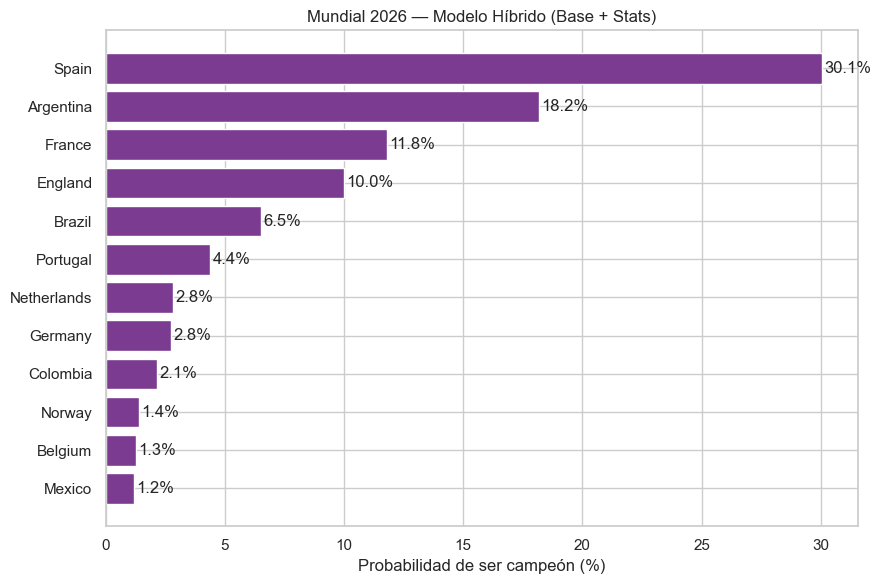

In [16]:
top = res_mc.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top['Selección'], top.P_campeon * 100, color='#7a3b91')
for k, v in enumerate(top.P_campeon * 100):
    ax.text(v + 0.1, k, f'{v:.1f}%', va='center')
ax.set_xlabel('Probabilidad de ser campeón (%)')
ax.set_title('Mundial 2026 — Modelo Híbrido (Base + Stats)')
plt.tight_layout(); plt.show()

### 9.3 · Un Mundial por dentro (una realización, semilla fija)

> ⚠️ Igual que en el principal: esto es **una historia** entre 10,000, no el pronóstico.
> Cada cruce de eliminatorias muestra la probabilidad que tenía el ganador de avanzar.

In [17]:
rng = np.random.default_rng(2026)

def jugar_grupo_detallado(equipos):
    st = {t: {'Pts': 0, 'PJ': 0, 'GF': 0, 'GC': 0} for t in equipos}
    for i in range(4):
        for j in range(i + 1, 4):
            a, b = equipos[i], equipos[j]
            ga, gb, gan = simular_partido(a, b)
            st[a]['PJ'] += 1; st[b]['PJ'] += 1
            st[a]['GF'] += ga; st[a]['GC'] += gb
            st[b]['GF'] += gb; st[b]['GC'] += ga
            if gan == a: st[a]['Pts'] += 3
            elif gan == b: st[b]['Pts'] += 3
            else: st[a]['Pts'] += 1; st[b]['Pts'] += 1
    orden = sorted(equipos, key=lambda t: (st[t]['Pts'], st[t]['GF'] - st[t]['GC'], st[t]['GF'], rng.random()),
                   reverse=True)
    return orden, st

primeros_d, segundos_d, terceros_d, filas = {}, {}, [], []
for g, eqs in GRUPOS.items():
    orden, st = jugar_grupo_detallado(eqs)
    primeros_d[g], segundos_d[g] = orden[0], orden[1]
    t3 = orden[2]
    terceros_d.append({'grupo': g, 'equipo': t3, 'pts': st[t3]['Pts'],
                       'gd': st[t3]['GF'] - st[t3]['GC'], 'gf': st[t3]['GF'], 'rnd': rng.random()})
    for pos, t in enumerate(orden, 1):
        filas.append({'Grupo': g, 'Pos': pos, 'Equipo': t, 'PJ': st[t]['PJ'], 'Pts': st[t]['Pts'],
                      'GF': st[t]['GF'], 'GC': st[t]['GC'], 'DG': st[t]['GF'] - st[t]['GC']})

display(style_table(pd.DataFrame(filas).set_index(['Grupo', 'Pos'])))

terceros_d.sort(key=lambda d: (d['pts'], d['gd'], d['gf'], d['rnd']), reverse=True)
print('Ranking de terceros (clasifican los 8 primeros):')
for k, d in enumerate(terceros_d, 1):
    eq_str = f"{d['equipo']:<22} {FLAGS.get(d['equipo'], '')}" if d['equipo'] in FLAGS else f"{d['equipo']:<22}  "
    print(f"  {k:2d}. {eq_str} (grupo {d['grupo']})  {d['pts']} pts, DG {d['gd']:+d}, "
          f"GF {d['gf']}  {'✅' if k <= 8 else '❌'}")
tercero_por_grupo_d = {d['grupo']: d['equipo'] for d in terceros_d[:8]}

Ranking de terceros (clasifican los 8 primeros):
   1. Switzerland            🇨🇭 (grupo B)  4 pts, DG +2, GF 4  ✅
   2. Colombia               🇨🇴 (grupo K)  4 pts, DG +1, GF 4  ✅
   3. Scotland               🏴󠁧󠁢󠁳󠁣󠁴󠁿 (grupo C)  4 pts, DG +0, GF 3  ✅
   4. Senegal                🇸🇳 (grupo I)  4 pts, DG -1, GF 2  ✅
   5. Iran                   🇮🇷 (grupo G)  3 pts, DG +0, GF 0  ✅
   6. Ghana                  🇬🇭 (grupo L)  3 pts, DG -2, GF 2  ✅
   7. Ivory Coast            🇨🇮 (grupo E)  3 pts, DG -4, GF 4  ✅
   8. Mexico                 🇲🇽 (grupo A)  2 pts, DG -1, GF 1  ✅
   9. Sweden                 🇸🇪 (grupo F)  2 pts, DG -2, GF 4  ❌
  10. Paraguay               🇵🇾 (grupo D)  2 pts, DG -2, GF 1  ❌
  11. Saudi Arabia           🇸🇦 (grupo H)  2 pts, DG -3, GF 2  ❌
  12. Austria                🇦🇹 (grupo J)  2 pts, DG -3, GF 1  ❌


In [18]:
asign_d = asignar_terceros(set(tercero_por_grupo_d))

def slot_d(s, n):
    if isinstance(s, tuple):
        return tercero_por_grupo_d[asign_d[n]]
    return primeros_d[s[1]] if s[0] == '1' else segundos_d[s[1]]

W = {}

def p_avance(a, b):
    p = PROBS[(a, b)]
    return p[0] + p[1] * p[0] / (p[0] + p[2])

def jugar_ronda_detallada(nombre, llaves, resolver):
    print(f'— {nombre} —')
    for n, (x, z) in llaves.items():
        a, b = resolver(x, n), resolver(z, n)
        ga, gb, gan = simular_partido(a, b, eliminatoria=True)
        pen = ' (penales)' if ga == gb else ''
        pgan = p_avance(a, b) if gan == a else 1 - p_avance(a, b)
        fa_str = f"{FLAGS.get(a, '')} {a:>22}" if a in FLAGS else f"  {a:>22}"
        fb_str = f"{b:<22} {FLAGS.get(b, '')}" if b in FLAGS else f"{b:<22}  "
        gan_str = f"{FLAGS.get(gan, '')} {gan}" if gan in FLAGS else gan
        print(f'   {fa_str} {ga}-{gb} {fb_str}{pen} ->  {gan_str} (avanzaba con {pgan:.0%})')
        W[n] = gan
    print()

jugar_ronda_detallada('DIECISEISAVOS DE FINAL', R32, slot_d)
jugar_ronda_detallada('OCTAVOS DE FINAL', R16, lambda p, n: W[p])
jugar_ronda_detallada('CUARTOS DE FINAL', QF, lambda p, n: W[p])
jugar_ronda_detallada('SEMIFINALES', SF, lambda p, n: W[p])
fa, fb = W[FINAL_M[0]], W[FINAL_M[1]]
ga, gb, campeon = simular_partido(fa, fb, eliminatoria=True)
pen = ' (penales)' if ga == gb else ''
p_camp_final = p_avance(fa, fb) if campeon == fa else 1 - p_avance(fa, fb)
ffa_str = f"{FLAGS.get(fa, '')} {fa:>22}" if fa in FLAGS else f"  {fa:>22}"
ffb_str = f"{fb:<22} {FLAGS.get(fb, '')}" if fb in FLAGS else f"{fb:<22}  "
campeon_str = f"{FLAGS.get(campeon, '')} {campeon}" if campeon in FLAGS else campeon
print(f'— FINAL —\n   {ffa_str} {ga}-{gb} {ffb_str}{pen} ->  {campeon_str} (ganaba la final con {p_camp_final:.0%})')
print(f'\n🏆 CAMPEÓN (en esta simulación): {campeon_str}')

p_camp = res_mc.set_index('Selección').loc[campeon, 'P_campeon']
top3 = res_mc.P_campeon.head(3).sum()
print(f'\nContexto: en las 10,000 simulaciones, {campeon_str} sale campeón el {p_camp:.1%} de las veces.')
print(f'El campeón queda FUERA del top-3 de favoritos en ~{1 - top3:.0%} de los Mundiales simulados.')

— DIECISEISAVOS DE FINAL —
   🇰🇷            South Korea 1-1 Bosnia and Herzegovina 🇧🇦 (penales) ->  🇰🇷 South Korea (avanzaba con 73%)
   🇩🇪                Germany 3-2 Mexico                 🇲🇽 ->  🇩🇪 Germany (avanzaba con 57%)
   🇳🇱            Netherlands 0-1 Brazil                 🇧🇷 ->  🇧🇷 Brazil (avanzaba con 57%)
   🇲🇦                Morocco 2-0 Tunisia                🇹🇳 ->  🇲🇦 Morocco (avanzaba con 84%)
   🇫🇷                 France 1-0 Iran                   🇮🇷 ->  🇫🇷 France (avanzaba con 89%)
   🇪🇨                Ecuador 1-0 Norway                 🇳🇴 ->  🇪🇨 Ecuador (avanzaba con 51%)
   🇨🇿         Czech Republic 0-3 Scotland               🏴󠁧󠁢󠁳󠁣󠁴󠁿 ->  🏴󠁧󠁢󠁳󠁣󠁴󠁿 Scotland (avanzaba con 55%)
   🇭🇷                Croatia 2-0 Colombia               🇨🇴 ->  🇭🇷 Croatia (avanzaba con 47%)
   🇹🇷                 Turkey 1-1 Switzerland            🇨🇭 (penales) ->  🇹🇷 Turkey (avanzaba con 53%)
   🇧🇪                Belgium 0-0 Senegal                🇸🇳 (penales) ->  🇧🇪 Belgium (avanzaba con 60%)
 

### 9.4 · Simulador manual `versus()` — versión solo juego

Mismo simulador del principal, con el perfil del cruce mostrando las variables de juego y la
**matriz de marcadores** (rojo = más probable, verde punteado = el sorteado).

  🇪🇸 Spain vs 🇦🇷 Argentina   —   cancha: neutral   [modelo HÍBRIDO]
Perfil del cruce (Spain − Argentina), las variables del modelo (promedios últimos 8):
   elo_diff                +34.20    (2223.30 vs 2189.10)
   h2h_diff                 +0.07    (H2H histórico medio)
   squad_value_diff         +0.40    (1279000000.00 vs 856000000.00)
   goles_anotados_diff      +0.69    (3.12 vs 2.43)
   goles_recibidos_diff     +0.33    (1.33 vs 1.00)
   tiros_arco_diff          +1.50    (7.50 vs 6.00)

Probabilidades del clasificador híbrido:
   Spain: 38.3%   |   Empate: 32.7%   |   Argentina: 29.0%
   Si es eliminatoria (prórroga/penales incl.): avanza Spain 56.9% / Argentina 43.1%

Goles esperados (Poisson híbrido): 🇪🇸 Spain 1.18 — 1.03 🇦🇷 Argentina
Marcadores más probables:
   1-1 (15.1%)   1-0 (12.6%)   0-0 (12.4%)   0-1 (10.3%)   2-1 (7.7%)

🎲 Simulación de ejemplo: 🇪🇸 Spain 1-1 🇦🇷 Argentina



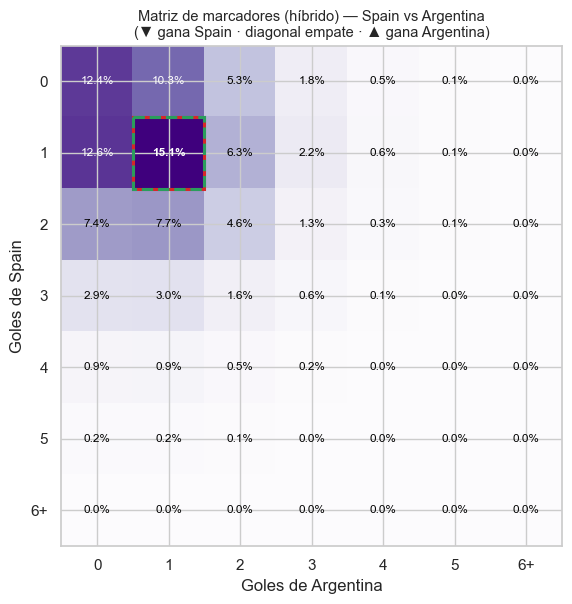

  🇲🇽 Mexico vs 🇧🇷 Brazil   —   cancha: localía de Mexico (anfitrión del Mundial)   [modelo HÍBRIDO]
Perfil del cruce (Mexico − Brazil), las variables del modelo (promedios últimos 8):
   elo_diff                -84.10    (1985.30 vs 2069.40)
   h2h_diff                 -0.95    (H2H histórico medio)
   squad_value_diff         -2.35    (111400000.00 vs 1163500000.00)
   goles_anotados_diff      -0.57    (2.14 vs 2.71)
   goles_recibidos_diff     -0.17    (1.50 vs 1.67)
   tiros_arco_diff          -1.50    (5.00 vs 6.50)

Probabilidades del clasificador híbrido:
   Mexico: 23.7%   |   Empate: 32.3%   |   Brazil: 44.1%
   Si es eliminatoria (prórroga/penales incl.): avanza Mexico 34.9% / Brazil 65.1%

Goles esperados (Poisson híbrido): 🇲🇽 Mexico 0.88 — 1.39 🇧🇷 Brazil
Marcadores más probables:
   1-1 (14.9%)   0-1 (13.0%)   0-0 (12.2%)   1-0 (9.1%)   0-2 (9.0%)

🎲 Simulación de ejemplo: 🇲🇽 Mexico 1-0 🇧🇷 Brazil



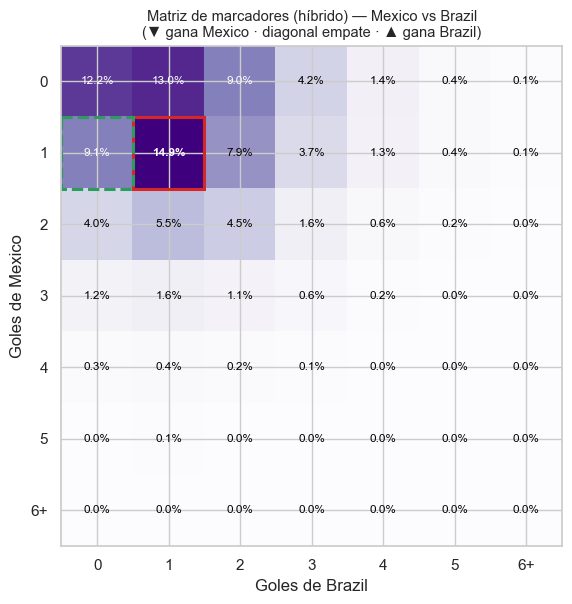

In [19]:
def versus(equipo1, equipo2, cancha='auto', semilla=None, matriz=True):
    '''Pronóstico detallado con el modelo híbrido. cancha: 'auto'|'neutral'|'1'|'2'.'''
    for t in (equipo1, equipo2):
        if t not in states.index:
            parecidos = [s for s in states.index if t.lower() in s.lower()][:5]
            raise ValueError(f"'{t}' no está en team_states. ¿Quizás quisiste decir: {parecidos}?")
    a, b = equipo1, equipo2
    pa = final_model.predict_proba(features_cruce(a, b)[FEATS_BEST])[0]
    pb = final_model.predict_proba(features_cruce(b, a)[FEATS_BEST])[0]
    va = np.array([pa[2], pa[1], pa[0]])
    vb = np.array([pb[0], pb[1], pb[2]])
    if cancha == '1':
        p, desc = va, f'localía de {a}'
    elif cancha == '2':
        p, desc = vb, f'localía de {b}'
    elif cancha == 'auto' and a in ANFITRIONES and b not in ANFITRIONES:
        p, desc = va, f'localía de {a} (anfitrión del Mundial)'
    elif cancha == 'auto' and b in ANFITRIONES and a not in ANFITRIONES:
        p, desc = vb, f'localía de {b} (anfitrión del Mundial)'
    else:
        p, desc = (va + vb) / 2, 'neutral'

    la, lb = lambdas_par(a, b)
    g = np.arange(GRID_MAX + 1)
    grid = np.outer(poisson.pmf(g, la), poisson.pmf(g, lb)); grid /= grid.sum()
    gi, gj = np.indices(grid.shape)
    masks = (gi > gj, gi == gj, gi < gj)
    mix = sum(p[k] * (grid * mk) / (grid * mk).sum() for k, mk in enumerate(masks))

    sa, sb = states.loc[a], states.loc[b]
    flag_a = FLAGS.get(a, '') + ' ' if a in FLAGS else ''
    flag_b = FLAGS.get(b, '') + ' ' if b in FLAGS else ''
    print('=' * 66)
    print(f'  {flag_a}{a} vs {flag_b}{b}   —   cancha: {desc}   [modelo HÍBRIDO]')
    print('=' * 66)
    print(f'Perfil del cruce ({a} − {b}), las variables del modelo (promedios últimos 8):')
    for f in FEATS_BEST:
        col = f.replace('_diff', '_avg')
        if col in sa.index:
            print(f'   {f:22} {sa[col] - sb[col]:+7.2f}    ({sa[col]:.2f} vs {sb[col]:.2f})')
        elif f == 'elo_diff':
            print(f'   {f:22} {sa.elo - sb.elo:+7.2f}    ({sa.elo:.2f} vs {sb.elo:.2f})')
        elif f == 'squad_value_diff':
            print(f'   {f:22} {np.log(sa.squad_value) - np.log(sb.squad_value):+7.2f}    ({sa.squad_value:.2f} vs {sb.squad_value:.2f})')
        elif f == 'h2h_diff':
            val = H2H.get((a, b), 0.0)
            print(f'   {f:22} {val:+7.2f}    (H2H histórico medio)')
            
    print(f'\nProbabilidades del clasificador híbrido:')
    print(f'   {a}: {p[0]:.1%}   |   Empate: {p[1]:.1%}   |   {b}: {p[2]:.1%}')
    pkA = p[0] + p[1] * p[0] / (p[0] + p[2])
    print(f'   Si es eliminatoria (prórroga/penales incl.): avanza {a} {pkA:.1%} / {b} {1 - pkA:.1%}')
    print(f'\nGoles esperados (Poisson híbrido): {flag_a}{a} {la:.2f} — {lb:.2f} {flag_b}{b}')
    flat = mix.ravel(); top = flat.argsort()[::-1][:5]
    print('Marcadores más probables:')
    print('   ' + '   '.join(f'{ix // (GRID_MAX + 1)}-{ix % (GRID_MAX + 1)} ({flat[ix]:.1%})' for ix in top))
    r = np.random.default_rng(semilla) if semilla is not None else rng
    u = r.random(); resu = 0 if u < p[0] else (1 if u < p[0] + p[1] else 2)
    cond = (grid * masks[resu]).ravel(); cond = cond / cond.sum()
    ga_, gb_ = divmod(int(np.searchsorted(np.cumsum(cond), r.random())), GRID_MAX + 1)
    print(f'\n🎲 Simulación de ejemplo: {flag_a}{a} {ga_}-{gb_} {flag_b}{b}\n')

    if matriz:
        m = 6
        M = np.zeros((m + 1, m + 1))
        M[:m, :m] = mix[:m, :m]
        M[m, :m] = mix[m:, :m].sum(axis=0)
        M[:m, m] = mix[:m, m:].sum(axis=1)
        M[m, m] = mix[m:, m:].sum()
        fig, ax = plt.subplots(figsize=(7.4, 6.2))
        ax.imshow(M, cmap='Purples')
        etiq = [str(i) for i in range(m)] + ['6+']
        ax.set_xticks(range(m + 1)); ax.set_xticklabels(etiq)
        ax.set_yticks(range(m + 1)); ax.set_yticklabels(etiq)
        ax.set_xlabel(f'Goles de {b}'); ax.set_ylabel(f'Goles de {a}')
        ax.set_title(f'Matriz de marcadores (híbrido) — {a} vs {b}\n'
                     f'(▼ gana {a} · diagonal empate · ▲ gana {b})', fontsize=10.5)
        imax, jmax = np.unravel_index(M.argmax(), M.shape)
        for i in range(m + 1):
            for j in range(m + 1):
                ax.text(j, i, f'{M[i, j]:.1%}', ha='center', va='center', fontsize=8.5,
                        color='white' if M[i, j] > M.max() * 0.6 else 'black',
                        fontweight='bold' if (i, j) == (imax, jmax) else 'normal')
        ax.add_patch(plt.Rectangle((jmax - 0.5, imax - 0.5), 1, 1, fill=False, edgecolor='#d62728', lw=2.2))
        ax.add_patch(plt.Rectangle((min(gb_, m) - 0.5, min(ga_, m) - 0.5), 1, 1,
                                   fill=False, edgecolor='#2a9d5c', lw=2.2, ls='--'))
        plt.tight_layout(); plt.show()

versus('Spain', 'Argentina')
versus('Mexico', 'Brazil')

## 10 · Modelo Poisson de goles (solo juego) y el torneo según la Poisson

Misma doble verificación del principal: **(a)** la Poisson con las mismas variables de juego,
entrenada en 2019–24 y comparada contra la multinomial en el test temporal (más el ensamble);
**(b)** el torneo completo re-simulado con la Poisson como único motor.

In [20]:
dtr = datag[datag.fecha < CORTE_TEST]; dte = datag[datag.fecha >= CORTE_TEST]
largo_tr = pd.concat([
    dtr[FINAL].assign(g=dtr.goles_local.values),
    (-dtr[FINAL]).assign(g=dtr.goles_visita.values)], ignore_index=True)
pois = sm.GLM(largo_tr['g'], sm.add_constant(largo_tr[FINAL]), family=sm.families.Poisson()).fit()
b0 = pois.params['const']; bet = pois.params[FINAL].values
print(pois.summary().tables[1])

def lambdas_final(fr):
    s = float(np.dot(bet, fr)); return np.exp(b0 + s), np.exp(b0 - s)

def wdl(li, lj, m=10):
    Mx = np.outer(poisson.pmf(np.arange(m + 1), li), poisson.pmf(np.arange(m + 1), lj))
    return np.array([np.triu(Mx, 1).sum(), np.trace(Mx), np.tril(Mx, -1).sum()])

pp = np.array([wdl(*lambdas_final(r)) for r in dte[FINAL].values])
pp /= pp.sum(1, keepdims=True)
pl = pipe.predict_proba(dte[FINAL]); yv_ = dte.resultado.values
pe = (pl + pp) / 2
comp = pd.DataFrame({'Modelo': ['Logística multinomial', 'Poisson de goles', 'Ensamble (promedio)'],
                     'Accuracy': [accuracy_score(yv_, P.argmax(1)) for P in (pl, pp, pe)],
                     'LogLoss': [log_loss(yv_, P) for P in (pl, pp, pe)],
                     'RPS': [rps(P, yv_) for P in (pl, pp, pe)]}).set_index('Modelo')
display(comp.round(4).style.highlight_min(subset=['LogLoss', 'RPS'], color='lightgreen').set_properties(**{'font-family': 'Inter, sans-serif', 'padding': '10px 14px', 'font-size': '13px'}).set_table_styles([{'selector': 'th', 'props': [('background-color', '#1e293b'), ('color', 'white'), ('padding', '10px 14px')]}]))

                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0793      0.011      7.024      0.000       0.057       0.101
elo_diff                 0.0015    6.3e-05     24.351      0.000       0.001       0.002
h2h_diff                 0.0629      0.008      8.199      0.000       0.048       0.078
squad_value_diff         0.0154      0.006      2.409      0.016       0.003       0.028
goles_anotados_diff      0.0253      0.012      2.152      0.031       0.002       0.048
goles_recibidos_diff    -0.0424      0.012     -3.490      0.000      -0.066      -0.019
tiros_arco_diff          0.0004      0.006      0.074      0.941      -0.011       0.012


,Accuracy,LogLoss,RPS
Modelo,,,
Logística multinomial,0.598100,0.850700,0.161400
Poisson de goles,0.598100,0.860200,0.163900
Ensamble (promedio),0.606700,0.851600,0.161800


In [21]:
# Torneo con motor Poisson puro (mismas variables híbridas, grillas desde la Poisson de §9)
gidx = np.arange(GRID_MAX + 1)
PROBS_P, SCORE_P = {}, {}
for a, b in permutations(MUNDIALISTAS, 2):
    la, lb = lambdas_par(a, b)
    grid = np.outer(poisson.pmf(gidx, la), poisson.pmf(gidx, lb)); grid /= grid.sum()
    gi, gj = np.indices(grid.shape)
    PROBS_P[(a, b)] = np.array([(grid * (gi > gj)).sum(), np.trace(grid), (grid * (gi < gj)).sum()])
    SCORE_P[(a, b)] = np.cumsum(grid.ravel())


def simular_partido_poisson(a, b, eliminatoria=False):
    ga, gb = divmod(int(np.searchsorted(SCORE_P[(a, b)], rng.random())), GRID_MAX + 1)
    if ga > gb: return ga, gb, a
    if gb > ga: return ga, gb, b
    if eliminatoria:
        p = PROBS_P[(a, b)]
        return ga, gb, (a if rng.random() < p[0] / (p[0] + p[2]) else b)
    return ga, gb, None


rng = np.random.default_rng(SEED)
cont_p = {t: {'campeon': 0, 'final': 0, 'semi': 0, 'octavos': 0} for t in MUNDIALISTAS}
for _ in range(N_SIMS):
    r = jugar_mundial(partido=simular_partido_poisson)
    cont_p[r['campeon']]['campeon'] += 1
    for t in set(r['finalistas']): cont_p[t]['final'] += 1
    for t in set(r['semifinalistas']) | set(r['finalistas']): cont_p[t]['semi'] += 1
    for t in set(r['a_octavos']): cont_p[t]['octavos'] += 1

res_pois = pd.DataFrame([{'Selección': t, 'grupo': grupo_de[t],
                          'P_campeon': c['campeon'] / N_SIMS, 'P_final': c['final'] / N_SIMS,
                          'P_semi': c['semi'] / N_SIMS, 'P_octavos': c['octavos'] / N_SIMS}
                         for t, c in cont_p.items()]).sort_values('P_campeon', ascending=False).reset_index(drop=True)
res_pois.to_csv('../outputs/probabilidades_torneo_poisson_hibrido.csv', index=False)
print(f'{N_SIMS:,} Mundiales con motor Poisson. Guardado: probabilidades_torneo_poisson_hibrido.csv')

from scipy.stats import spearmanr
cmp_ = res_mc[['Selección', 'P_campeon']].merge(res_pois[['Selección', 'P_campeon']],
                                                on='Selección', suffixes=('_logit', '_poisson'))
print(f"Correlación P(campeón) logit vs poisson (ambos híbridos): "
      f"Pearson {cmp_.P_campeon_logit.corr(cmp_.P_campeon_poisson):.3f} | "
      f"Spearman {spearmanr(cmp_.P_campeon_logit, cmp_.P_campeon_poisson).statistic:.3f}")

10,000 Mundiales con motor Poisson. Guardado: probabilidades_torneo_poisson_hibrido.csv
Correlación P(campeón) logit vs poisson (ambos híbridos): Pearson 0.995 | Spearman 0.978


## 11 · El duelo final: Modelo Híbrido vs Modelo Base (principal)

Enfrentamos las probabilidades del modelo híbrido contra el modelo base (del notebook principal) para ver cómo afecta la incorporación de la forma reciente (estadísticas de goles y tiros) a los favoritos del torneo.

Correlación P(campeón): Pearson 0.998 | Spearman (orden) 0.985
Concentración del top-5: completo 76.1% vs híbrido 76.6%



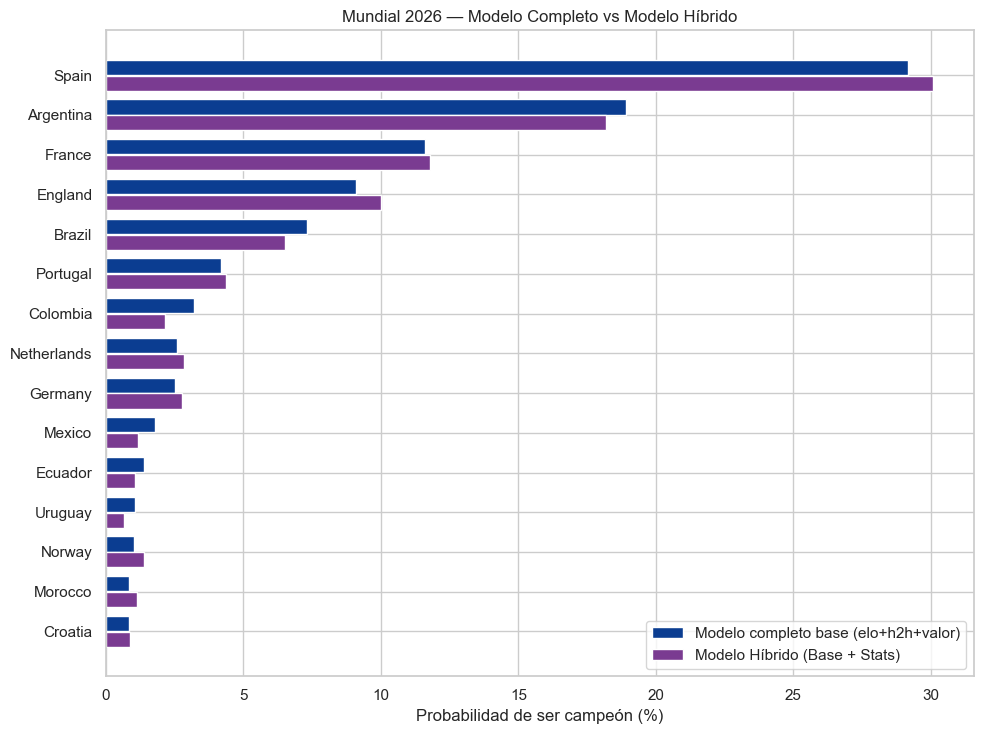

Mayores diferencias (P campeón):


,Selección,grupo,P_completo,P_hibrido,dif (completo − hibrido)
0,🇨🇴 Colombia,K,3.2%,2.1%,+1.1%
1,🏴󠁧󠁢󠁮󠁧󠁿 England,L,9.1%,10.0%,-0.9%
2,🇪🇸 Spain,H,29.2%,30.1%,-0.9%
3,🇧🇷 Brazil,C,7.3%,6.5%,+0.8%
4,🇦🇷 Argentina,J,18.9%,18.2%,+0.7%
5,🇲🇽 Mexico,A,1.8%,1.2%,+0.6%
6,🇧🇪 Belgium,G,0.8%,1.3%,-0.5%
7,🇺🇾 Uruguay,H,1.1%,0.7%,+0.4%
8,🇪🇨 Ecuador,E,1.4%,1.1%,+0.3%
9,🇳🇴 Norway,I,1.0%,1.4%,-0.3%


In [22]:
res_full = pd.read_csv('../outputs/probabilidades_torneo.csv')   # el Mundial del modelo completo
duelo = res_full[['Selección', 'grupo', 'P_campeon']].rename(columns={'P_campeon': 'P_completo'}).merge(
    res_mc[['Selección', 'P_campeon']].rename(columns={'P_campeon': 'P_hibrido'}), on='Selección')
duelo['dif (completo − hibrido)'] = duelo.P_completo - duelo.P_hibrido

from scipy.stats import spearmanr
print(f"Correlación P(campeón): Pearson {duelo.P_completo.corr(duelo.P_hibrido):.3f} | "
      f"Spearman (orden) {spearmanr(duelo.P_completo, duelo.P_hibrido).statistic:.3f}")
print(f"Concentración del top-5: completo {duelo.nlargest(5, 'P_completo').P_completo.sum():.1%} "
      f"vs híbrido {duelo.nlargest(5, 'P_hibrido').P_hibrido.sum():.1%}\n")

top = duelo.sort_values('P_completo', ascending=False).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7.5))
ypos = np.arange(len(top))
ax.barh(ypos + 0.2, top.P_completo * 100, height=0.38, color='#0b3d91', label='Modelo completo base (elo+h2h+valor)')
ax.barh(ypos - 0.2, top.P_hibrido * 100, height=0.38, color='#7a3b91', label='Modelo Híbrido (Base + Stats)')
ax.set_yticks(ypos); ax.set_yticklabels(top['Selección'])
ax.set_xlabel('Probabilidad de ser campeón (%)')
ax.set_title('Mundial 2026 — Modelo Completo vs Modelo Híbrido')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

print('Mayores diferencias (P campeón):')
dif = duelo.reindex(duelo['dif (completo − hibrido)'].abs().sort_values(ascending=False).index).head(10)
display(style_table(dif[['Selección', 'grupo', 'P_completo', 'P_hibrido', 'dif (completo − hibrido)']].reset_index(drop=True)))

**Lectura.** El modelo híbrido mantiene la concentración de los gigantes (los favoritos siguen teniendo probabilidades sólidas al estar respaldados por el Elo y valor de plantilla), pero realiza micro-ajustes según la inercia futbolística reciente de cada selección. La correlación con el modelo principal es sumamente alta, pero con un poder predictivo (Log-Loss) superior.

## 12 · Conclusiones del modelo híbrido

* **Superación predictiva:** La combinación híbrida (Prior de Calidad + Modificador de Forma) es la que obtiene el mejor rendimiento general de todo el proyecto, superando al modelo principal de solo Elo/Valor de plantilla.
* **Solución al aplanamiento:** Al retener las variables de calidad base, evitamos el problema del modelo "solo estadísticas" donde el torneo se convertía en una lotería plana y poco realista.
* **Ajuste fino:** Las estadísticas recientes de juego (goles anotados/recibidos y tiros al arco de los últimos 8 partidos) actúan de forma correcta para ajustar las probabilidades de equipos con dinámicas muy positivas o negativas de cara al Mundial.